<a href="https://colab.research.google.com/github/GUUlnaz/DZ2/blob/Hw_4/%D0%92%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

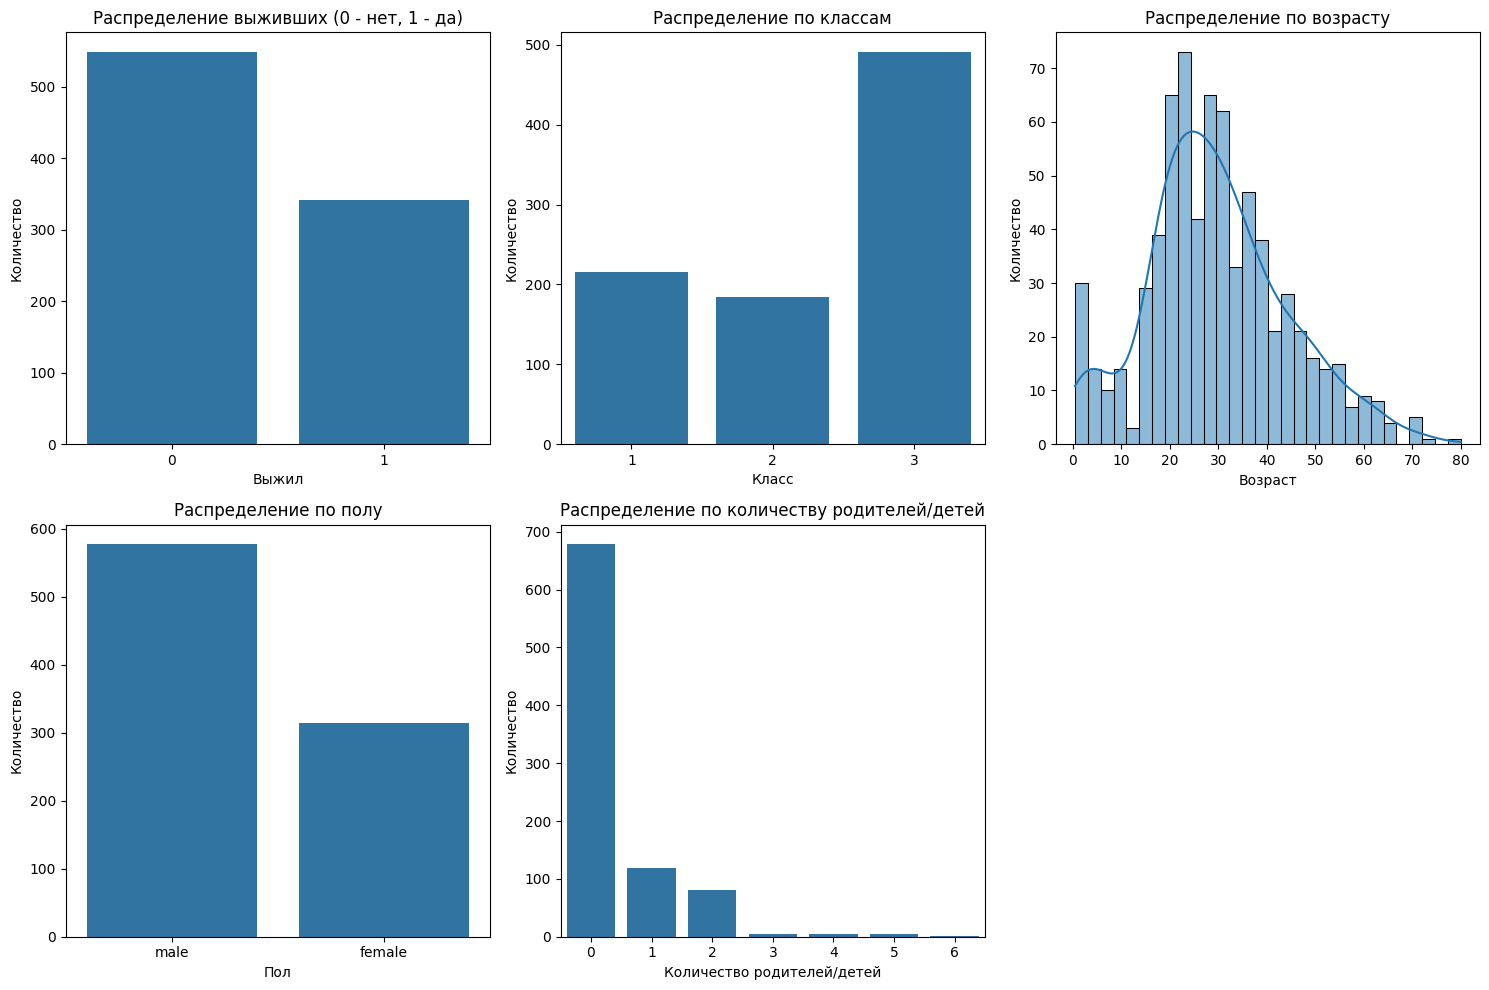

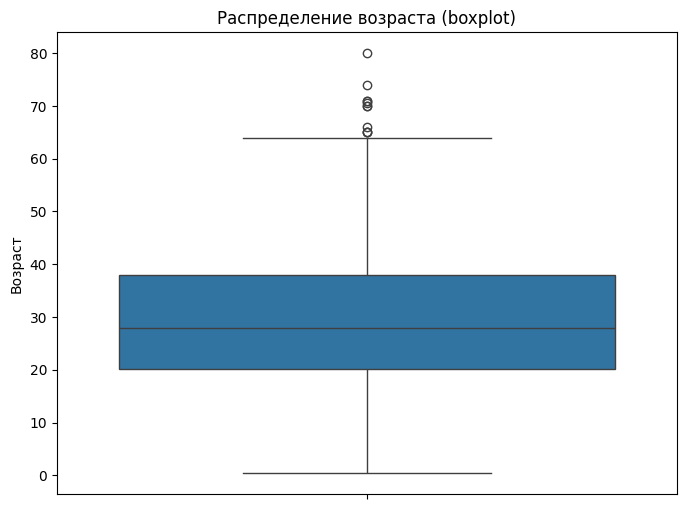


Интерпретация boxplot для Age:
- Средний возраст пассажиров около 28-30 лет (медиана)
- 25% пассажиров младше 20 лет (нижний ус)
- 75% пассажиров младше 38 лет (верхний ус)
- Есть выбросы - пожилые пассажиры старше 65 лет
- Минимальный возраст около 0.4 года (младенцы)



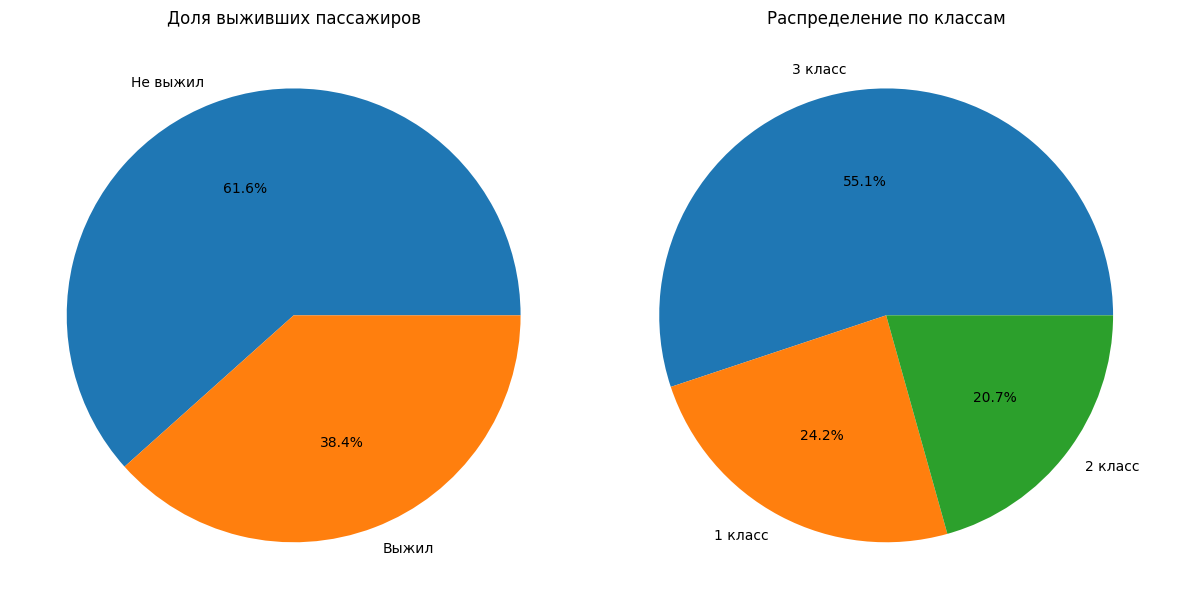

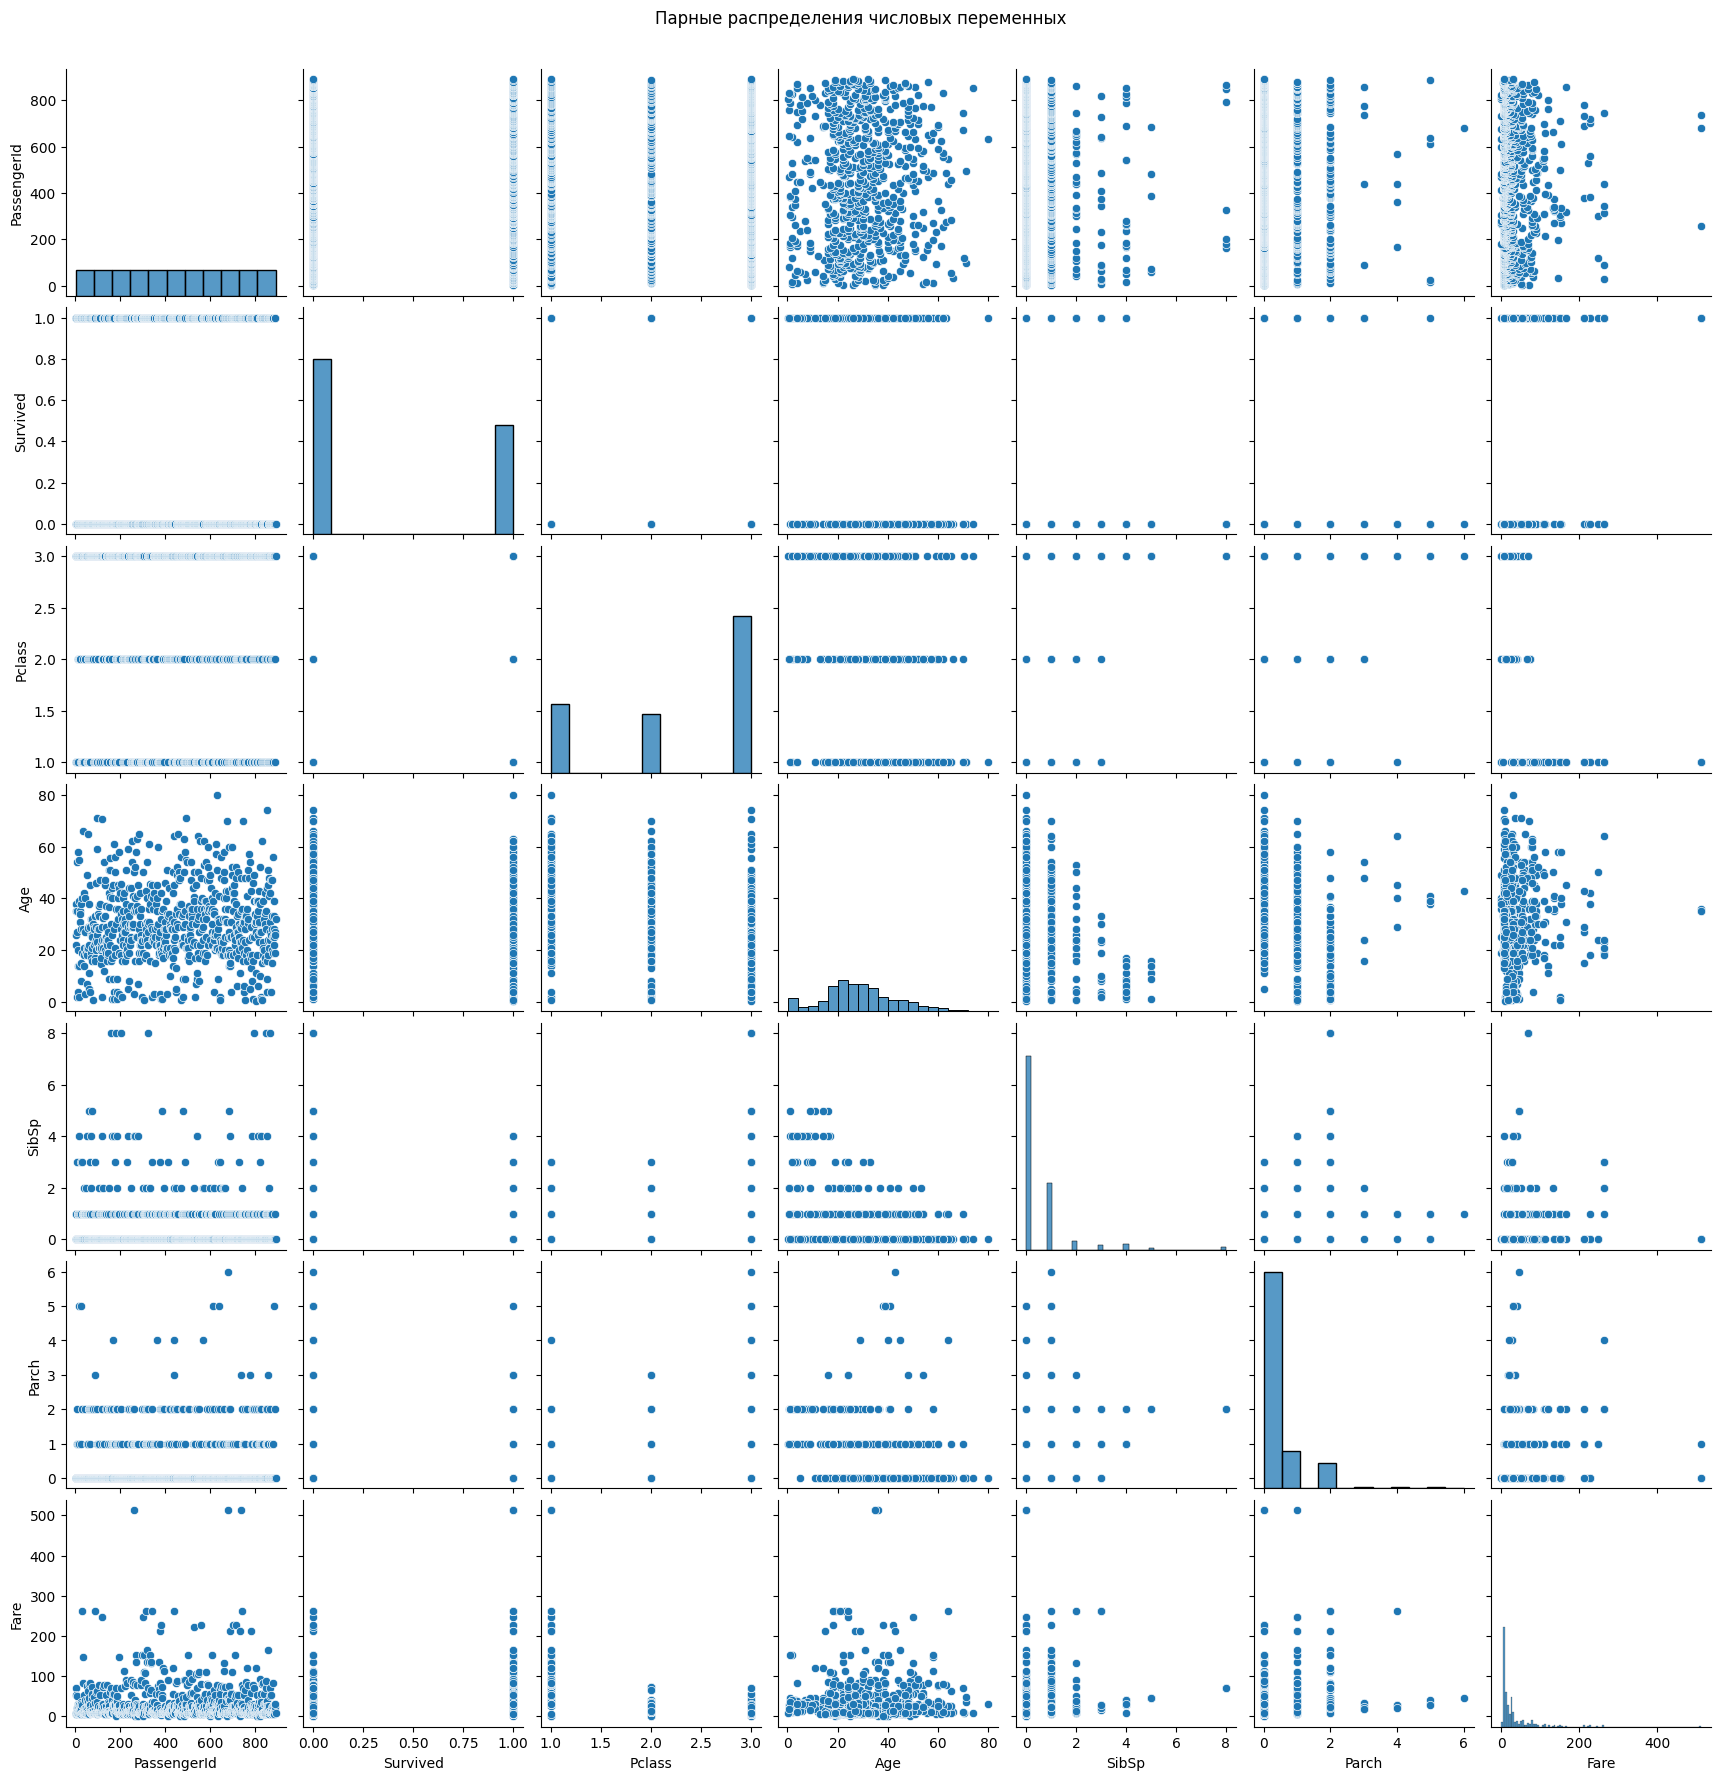

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Загрузка данных
df = pd.read_csv('/content/train (1).csv')

# 2. Визуализация распределения признаков
plt.figure(figsize=(15, 10))

# Survived
plt.subplot(2, 3, 1)
sns.countplot(data=df, x='Survived')
plt.title('Распределение выживших (0 - нет, 1 - да)')
plt.xlabel('Выжил')
plt.ylabel('Количество')

# Pclass
plt.subplot(2, 3, 2)
sns.countplot(data=df, x='Pclass')
plt.title('Распределение по классам')
plt.xlabel('Класс')
plt.ylabel('Количество')

# Age
plt.subplot(2, 3, 3)
sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.title('Распределение по возрасту')
plt.xlabel('Возраст')
plt.ylabel('Количество')

# Sex
plt.subplot(2, 3, 4)
sns.countplot(data=df, x='Sex')
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')

# Parch
plt.subplot(2, 3, 5)
sns.countplot(data=df, x='Parch')
plt.title('Распределение по количеству родителей/детей')
plt.xlabel('Количество родителей/детей')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

# 3. Boxplot для Age
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Age')
plt.title('Распределение возраста (boxplot)')
plt.ylabel('Возраст')
plt.show()

# 4. Интерпретация boxplot
print("""
Интерпретация boxplot для Age:
- Средний возраст пассажиров около 28-30 лет (медиана)
- 25% пассажиров младше 20 лет (нижний ус)
- 75% пассажиров младше 38 лет (верхний ус)
- Есть выбросы - пожилые пассажиры старше 65 лет
- Минимальный возраст около 0.4 года (младенцы)
""")

# 5. Pie charts для Survived и Pclass
plt.figure(figsize=(12, 6))

# Survived
plt.subplot(1, 2, 1)
survived_counts = df['Survived'].value_counts()
plt.pie(survived_counts, labels=['Не выжил', 'Выжил'], autopct='%1.1f%%')
plt.title('Доля выживших пассажиров')

# Pclass
plt.subplot(1, 2, 2)
pclass_counts = df['Pclass'].value_counts()
plt.pie(pclass_counts, labels=['3 класс', '1 класс', '2 класс'], autopct='%1.1f%%')
plt.title('Распределение по классам')

plt.tight_layout()
plt.show()

# 6. Pairplot для числовых переменных
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
sns.pairplot(df[numerical_cols])
plt.suptitle('Парные распределения числовых переменных', y=1.02)
plt.show()

# 7. Sunburst plot с помощью Plotly
fig = px.sunburst(
    df,
    path=['Pclass', 'Sex'],
    title='Иерархия пассажиров: Класс → Пол'
)
fig.update_traces(textinfo="label+percent parent")
fig.show()

# 8. Все графики уже снабжены названиями, подписями осей и легендами